## Mori Model

Random initial conditions, no stimulus

Replication of Fig. 2d from Mori et al.m (2008)


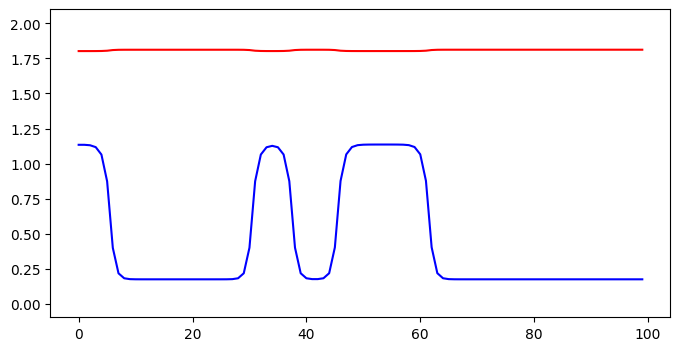

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter
from pde_utils import double_derivative

# random seed
np.random.seed(42)

# define parameters
Da = 0.1 # A diffusion rate
Db = 10 # B diffusion rate
delta = 1 # basal rate of inactivation
gamma = 1 # GTPase autocatalytic activation rate
K = 1 # saturation parameter
k0 = 0.067 # basal GEF conversion rate
size = 100 # number of cells
dt = 0.01  # time step
t = 1000.0 # run time
frame_int = 5 # animation frame interval
a0 = 0.2683312
b0 = 2.0

# set initial concentrations
A =  2 * a0 * np.random.rand(size)
B = np.full(size, b0)

# define reaction kinetics function
def f(a, b):
    return (k0 + gamma*a**2/(K**2 + a**2))*b - delta*a

# set up figure
fig, ax = plt.subplots(figsize=(8, 4))
frames = []

# simulate the PDE with finite difference method
for i in range(int(t/dt)):

    # update concentrations
    A = A + dt * (Da * double_derivative(A) + f(A, B))
    B = B + dt * (Db * double_derivative(B) - f(A, B))

    # apply Neumann boundary conditions
    for Z in (A, B):
        Z[0] = Z[1]
        Z[-1] = Z[-2]

    # capture a frame every frame_int seconds
    if i % int(frame_int/dt) == 0:
        ALine, = ax.plot(A, color='blue')
        BLine, = ax.plot(B, color="red")
        frames.append([ALine, BLine])

animation.ArtistAnimation(fig, frames, interval=100, blit=True).save('animations/mori_small_domain.gif', writer=PillowWriter(fps=10))